In [1]:
from google.colab import files
uploaded = files.upload()

Saving Inappapropriate_messages.csv to Inappapropriate_messages.csv


In [2]:
import pandas as pd

data = pd.read_csv('Inappapropriate_messages.csv')
print(data.head())

                                                text  inappropriate
0  Бедный Ниссон, его бесконечных детей то похища...         0.9526
1  Все кто лишился девстенности после NUMBER - ом...         0.9972
2  Не знаю сам почему её туда отправили. Не торга...         0.0217
3  Проституция легальнаНелегальное предпринимател...         0.9986
4  Я бы повстречался с порноактрисой, только я не...         0.9998


In [3]:
data['label'] = (data['inappropriate'] >= 0.5).astype(int)


In [4]:
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

# 1. Подготовка данных
train_df, val_df = train_test_split(data[['text', 'label']], test_size=0.2, random_state=42, stratify=data['label'])

# Создаем Dataset объекты
ds = DatasetDict({
    'train': Dataset.from_pandas(train_df.reset_index(drop=True)),
    'validation': Dataset.from_pandas(val_df.reset_index(drop=True))
})

# Загрузка токенизатора и модели
MODEL_NAME = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=False, max_length=512)

tokenized_datasets = ds.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Загружаем модель для классификации
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

config.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/21.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

Map:   0%|          | 0/99677 [00:00<?, ? examples/s]

Map:   0%|          | 0/24920 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

# Настройка параметров обучения
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# Инициализация Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Запуск обучения
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.287795,0.281495,0.882143,0.880443
2,0.148243,0.417844,0.881822,0.881036
3,0.044044,0.734828,0.878812,0.878152


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=18690, training_loss=0.17466843780060387, metrics={'train_runtime': 3172.6102, 'train_samples_per_second': 94.254, 'train_steps_per_second': 5.891, 'total_flos': 1.3782486178422192e+16, 'train_loss': 0.17466843780060387, 'epoch': 3.0})

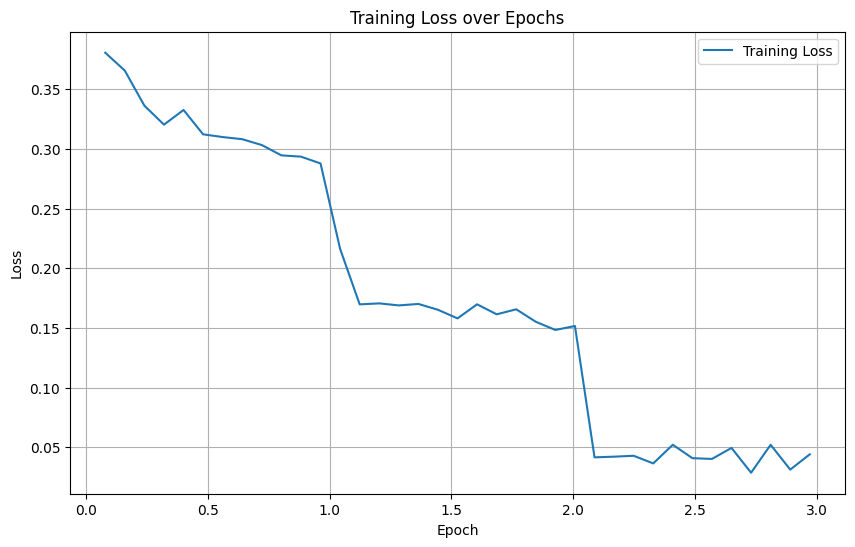

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

train_metrics = []
eval_metrics = []
for log in trainer.state.log_history:
    if 'loss' in log and 'learning_rate' in log:
        train_metrics.append(log)
    elif 'eval_loss' in log:
        eval_metrics.append(log)


train_loss_values = [m['loss'] for m in train_metrics]
train_epochs_values = [m['epoch'] for m in train_metrics]


plt.figure(figsize=(10, 6))
sns.lineplot(x=train_epochs_values, y=train_loss_values, label='Training Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
from transformers import pipeline

if 'model' not in locals() or 'tokenizer' not in locals():
    print("Модель или токенизатор не загружены. Загружаю...")
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    MODEL_NAME = "deepvk/RuModernBERT-base"

# Если модель была обучена, то она уже должна быть в переменной `model` и `tokenizer`
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)

def predict_toxicity(text):
    result = classifier(text)
    predicted_label = int(result[0]['label'].split('_')[1]) # Извлекаем 0 или 1
    return "Токсичный" if predicted_label == 1 else "Нетоксичный"

# Пример использования
example_text1 = "Это очень хороший и полезный комментарий!"
example_text2 = "Таких как ты на войну надо отправлять"
example_text3 = "Я совершенно не согласен с вашим мнением. Можно ли объяснить подробнее?"

print(f"Текст: '{example_text1}' - Предсказание: {predict_toxicity(example_text1)}")
print(f"Текст: '{example_text2}' - Предсказание: {predict_toxicity(example_text2)}")
print(f"Текст: '{example_text3}' - Предсказание: {predict_toxicity(example_text3)}")

Текст: 'Это очень хороший и полезный комментарий!' - Предсказание: Нетоксичный
Текст: 'Таких как ты на войну надо отправлять' - Предсказание: Токсичный
Текст: 'Я совершенно не согласен с вашим мнением. Можно ли объяснить подробнее?' - Предсказание: Нетоксичный


In [10]:
import os
import shutil

# Сохраняем модель и токенизатор
output_dir = "./toxic_model"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

# Архивируем модель
shutil.make_archive(output_dir, 'zip', output_dir)
print(f"Модель и токенизатор сохранены и заархивированы в {output_dir}.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель и токенизатор сохранены и заархивированы в ./toxic_model.zip
